In [1]:
import time
import json
import numpy as np
import pandas as pd

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [9]:
import shap
import matplotlib.pyplot as plt

In [10]:
path = r"C:\Users\ashme\Downloads\HealthcareFraudDataset"
 
train = pd.read_csv(path + r"\Train-1542865627584.csv")
beneficiary = pd.read_csv(path + r"\Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv(path + r"\Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv(path + r"\Train_Outpatientdata-1542865627584.csv")
 
print("Loaded:", train.shape, beneficiary.shape, inpatient.shape, outpatient.shape)

Loaded: (5410, 2) (138556, 25) (40474, 30) (517737, 27)


In [11]:
inpatient = inpatient.copy()
outpatient = outpatient.copy()
inpatient["ClaimType"] = "Inpatient"
outpatient["ClaimType"] = "Outpatient"
 
common_cols = list(set(inpatient.columns) & set(outpatient.columns))
claims = pd.concat([inpatient[common_cols], outpatient[common_cols]], ignore_index=True)
 
claims["ClaimStartDt"] = pd.to_datetime(claims["ClaimStartDt"])
claims["ClaimEndDt"] = pd.to_datetime(claims["ClaimEndDt"])
claims["ClaimDuration"] = (claims["ClaimEndDt"] - claims["ClaimStartDt"]).dt.days
 
beneficiary = beneficiary.copy()
beneficiary["DOB"] = pd.to_datetime(beneficiary["DOB"])
beneficiary["Age"] = 2009 - beneficiary["DOB"].dt.year  # dataset covers 2008-2009 claims
 
bene_cols = [
    "BeneID", "Age", "ChronicCond_Diabetes", "ChronicCond_Heartfailure",
    "ChronicCond_KidneyDisease", "IPAnnualReimbursementAmt", "OPAnnualReimbursementAmt",
]
claims = claims.merge(beneficiary[bene_cols], on="BeneID", how="left")
 
agg = claims.groupby("Provider").agg(
    num_claims=("ClaimID", "count"),
    num_unique_patients=("BeneID", "nunique"),
    num_unique_attending_phys=("AttendingPhysician", "nunique"),
    num_unique_operating_phys=("OperatingPhysician", "nunique"),
    total_reimbursed=("InscClaimAmtReimbursed", "sum"),
    avg_reimbursed=("InscClaimAmtReimbursed", "mean"),
    std_reimbursed=("InscClaimAmtReimbursed", "std"),
    max_reimbursed=("InscClaimAmtReimbursed", "max"),
    total_deductible=("DeductibleAmtPaid", "sum"),
    avg_claim_duration=("ClaimDuration", "mean"),
    avg_patient_age_proxy=("Age", "mean"),
    pct_chronic_diabetes=("ChronicCond_Diabetes", lambda s: (s == 1).mean()),
    pct_chronic_heartfailure=("ChronicCond_Heartfailure", lambda s: (s == 1).mean()),
    pct_chronic_kidney=("ChronicCond_KidneyDisease", lambda s: (s == 1).mean()),
    avg_ip_annual_reimbursed=("IPAnnualReimbursementAmt", "mean"),
    avg_op_annual_reimbursed=("OPAnnualReimbursementAmt", "mean"),
).reset_index()
 
claim_type_counts = claims.groupby(["Provider", "ClaimType"]).size().unstack(fill_value=0)
claim_type_counts = claim_type_counts.rename(columns={
    "Inpatient": "num_inpatient_claims", "Outpatient": "num_outpatient_claims"
}).reset_index()
 
df = agg.merge(claim_type_counts, on="Provider", how="left")
df["claims_per_patient"] = df["num_claims"] / df["num_unique_patients"]
df["reimbursed_per_patient"] = df["total_reimbursed"] / df["num_unique_patients"]
df["inpatient_ratio"] = df["num_inpatient_claims"] / df["num_claims"]
 
train["FraudLabel"] = (train["PotentialFraud"] == "Yes").astype(int)
df = df.merge(train[["Provider", "FraudLabel"]], on="Provider", how="inner")
 
df.to_csv(path + r"\provider_features.csv", index=False)
print("Saved provider_features.csv:", df.shape)
print("Fraud rate:", df["FraudLabel"].mean())
 

Saved provider_features.csv: (5410, 23)
Fraud rate: 0.09353049907578559


In [12]:
df = pd.read_csv(path + r"\provider_features.csv")
 
feature_cols = [
    "num_claims", "num_unique_patients", "num_unique_attending_phys",
    "num_unique_operating_phys", "total_reimbursed", "avg_reimbursed",
    "std_reimbursed", "max_reimbursed", "total_deductible",
    "avg_claim_duration", "num_inpatient_claims", "num_outpatient_claims",
    "claims_per_patient", "reimbursed_per_patient", "inpatient_ratio",
    "avg_patient_age_proxy", "pct_chronic_diabetes", "pct_chronic_heartfailure",
    "pct_chronic_kidney", "avg_ip_annual_reimbursed", "avg_op_annual_reimbursed",
]
 
X = df[feature_cols].fillna(0)
y = df["FraudLabel"].values
 
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, stratify=y, random_state=42
)
 
print(f"Train: {X_train.shape[0]} providers, {y_train.sum()} fraud ({y_train.mean():.2%})")
print(f"Test: {X_test.shape[0]} providers, {y_test.sum()} fraud ({y_test.mean():.2%})")

Train: 4328 providers, 405 fraud (9.36%)
Test: 1082 providers, 101 fraud (9.33%)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
fraud_rate_train = y_train.mean()
results_test = {}
 
def evaluate(name, y_true, y_pred_binary, anomaly_score, runtime):
    precision = precision_score(y_true, y_pred_binary, zero_division=0)
    recall = recall_score(y_true, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    roc_auc = roc_auc_score(y_true, anomaly_score)
    pr_auc = average_precision_score(y_true, anomaly_score)
    n_flagged = int(y_pred_binary.sum())
    cm = confusion_matrix(y_true, y_pred_binary)
    results_test[name] = {
        "Precision": precision, "Recall": recall, "F1": f1,
        "ROC-AUC": roc_auc, "PR-AUC": pr_auc,
        "Runtime(s)": runtime, "Flagged": n_flagged,
        "ConfusionMatrix": cm.tolist(),
    }
    print(f"{name}: P={precision:.3f} R={recall:.3f} F1={f1:.3f} "
          f"ROC-AUC={roc_auc:.3f} PR-AUC={pr_auc:.3f} "
          f"Flagged={n_flagged} Time={runtime:.2f}s")

In [25]:
print("Isolation Forest — contamination sweep:")
for c, f1v, rocv in zip(contam_values, iso_f1, iso_roc):
    print(f"  contamination={c:.4f}: F1={f1v:.3f}, ROC-AUC={rocv:.3f}")

print("\nLOF — n_neighbors sweep:")
for k, f1v, rocv in zip(k_values, lof_f1, lof_roc):
    print(f"  n_neighbors={k}: F1={f1v:.3f}, ROC-AUC={rocv:.3f}")

print("\nOC-SVM — nu sweep:")
for nu, f1v, rocv in zip(nu_values, ocsvm_f1, ocsvm_roc):
    print(f"  nu={nu:.4f}: F1={f1v:.3f}, ROC-AUC={rocv:.3f}")

Isolation Forest — contamination sweep:
  contamination=0.0200: F1=0.361, ROC-AUC=0.905
  contamination=0.0500: F1=0.480, ROC-AUC=0.905
  contamination=0.0935: F1=0.543, ROC-AUC=0.905
  contamination=0.1500: F1=0.539, ROC-AUC=0.905
  contamination=0.2000: F1=0.491, ROC-AUC=0.905

LOF — n_neighbors sweep:
  n_neighbors=5: F1=0.152, ROC-AUC=0.472
  n_neighbors=10: F1=0.133, ROC-AUC=0.519
  n_neighbors=20: F1=0.139, ROC-AUC=0.544
  n_neighbors=35: F1=0.171, ROC-AUC=0.587
  n_neighbors=50: F1=0.182, ROC-AUC=0.621

OC-SVM — nu sweep:
  nu=0.0200: F1=0.235, ROC-AUC=0.825
  nu=0.0500: F1=0.304, ROC-AUC=0.819
  nu=0.0935: F1=0.359, ROC-AUC=0.815
  nu=0.1500: F1=0.385, ROC-AUC=0.802
  nu=0.2000: F1=0.363, ROC-AUC=0.800


In [15]:
print("\n--- TEST SET RESULTS (models fit on train only) ---")
t0 = time.time()
iso = IsolationForest(contamination=fraud_rate_train, random_state=42, n_estimators=200)
iso.fit(X_train_scaled)
iso_test_score = -iso.score_samples(X_test_scaled)
iso_test_pred = (iso.predict(X_test_scaled) == -1).astype(int)
evaluate("Isolation Forest", y_test, iso_test_pred, iso_test_score, time.time() - t0)
 
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=fraud_rate_train, novelty=True)
lof.fit(X_train_scaled)
lof_test_score = -lof.decision_function(X_test_scaled)
lof_test_pred = (lof.predict(X_test_scaled) == -1).astype(int)
evaluate("Local Outlier Factor", y_test, lof_test_pred, lof_test_score, time.time() - t0)
 
t0 = time.time()
ocsvm = OneClassSVM(nu=fraud_rate_train, kernel="rbf", gamma="auto")
ocsvm.fit(X_train_scaled)
ocsvm_test_score = -ocsvm.decision_function(X_test_scaled)
ocsvm_test_pred = (ocsvm.predict(X_test_scaled) == -1).astype(int)
evaluate("One-Class SVM", y_test, ocsvm_test_pred, ocsvm_test_score, time.time() - t0)
 
t0 = time.time()
tf.random.set_seed(42)
input_dim = X_train_scaled.shape[1]
autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(12, activation="relu"),
    layers.Dense(max(4, input_dim // 3), activation="relu"),
    layers.Dense(12, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=64,
                shuffle=True, verbose=0, validation_split=0.1)
 
recon_train = autoencoder.predict(X_train_scaled, verbose=0)
recon_train_error = np.mean(np.square(X_train_scaled - recon_train), axis=1)
threshold = np.percentile(recon_train_error, 100 * (1 - fraud_rate_train))
 
recon_test = autoencoder.predict(X_test_scaled, verbose=0)
ae_test_score = np.mean(np.square(X_test_scaled - recon_test), axis=1)
ae_test_pred = (ae_test_score > threshold).astype(int)
evaluate("Autoencoder", y_test, ae_test_pred, ae_test_score, time.time() - t0)
 
with open(path + r"\test_set_results.json", "w") as f:
    json.dump(results_test, f, indent=2)



--- TEST SET RESULTS (models fit on train only) ---
Isolation Forest: P=0.500 R=0.594 F1=0.543 ROC-AUC=0.905 PR-AUC=0.553 Flagged=120 Time=1.78s
Local Outlier Factor: P=0.130 R=0.149 F1=0.139 ROC-AUC=0.544 PR-AUC=0.127 Flagged=115 Time=3.10s
One-Class SVM: P=0.336 R=0.386 F1=0.359 ROC-AUC=0.815 PR-AUC=0.344 Flagged=116 Time=1.02s
Autoencoder: P=0.153 R=0.168 F1=0.160 ROC-AUC=0.596 PR-AUC=0.123 Flagged=111 Time=45.20s


In [16]:
print("\n" + "=" * 60)
print("DOWNSTREAM SUPERVISED MODEL: does adding anomaly scores help?")
print("=" * 60)
 
iso_train_score = -iso.score_samples(X_train_scaled)
lof_train_score = -lof.decision_function(X_train_scaled)
ocsvm_train_score = -ocsvm.decision_function(X_train_scaled)
ae_train_score = recon_train_error
 
anomaly_train = np.column_stack([iso_train_score, lof_train_score, ocsvm_train_score, ae_train_score])
anomaly_test = np.column_stack([iso_test_score, lof_test_score, ocsvm_test_score, ae_test_score])
anomaly_cols = ["IsoForest_score", "LOF_score", "OCSVM_score", "Autoencoder_score"]
 
t0 = time.time()
rf_baseline = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_baseline.fit(X_train_scaled, y_train)
base_score = rf_baseline.predict_proba(X_test_scaled)[:, 1]
base_pred = rf_baseline.predict(X_test_scaled)
evaluate("RF Baseline (raw features only)", y_test, base_pred, base_score, time.time() - t0)
 
X_train_enhanced = np.hstack([X_train_scaled, anomaly_train])
X_test_enhanced = np.hstack([X_test_scaled, anomaly_test])
 
t0 = time.time()
rf_enhanced = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_enhanced.fit(X_train_enhanced, y_train)
enh_score = rf_enhanced.predict_proba(X_test_enhanced)[:, 1]
enh_pred = rf_enhanced.predict(X_test_enhanced)
evaluate("RF Enhanced (raw + anomaly-score features)", y_test, enh_pred, enh_score, time.time() - t0)
 
with open(path + r"\test_set_results.json", "w") as f:
    json.dump(results_test, f, indent=2)
 


DOWNSTREAM SUPERVISED MODEL: does adding anomaly scores help?
RF Baseline (raw features only): P=0.750 R=0.535 F1=0.624 ROC-AUC=0.952 PR-AUC=0.714 Flagged=72 Time=12.89s
RF Enhanced (raw + anomaly-score features): P=0.726 R=0.525 F1=0.609 ROC-AUC=0.954 PR-AUC=0.719 Flagged=73 Time=13.09s


In [17]:
all_feature_names = feature_cols + anomaly_cols
explainer = shap.TreeExplainer(rf_enhanced)
shap_values = explainer.shap_values(X_test_enhanced)
 
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
 
plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X_test_enhanced, feature_names=all_feature_names, show=False, max_display=12)
plt.tight_layout()
plt.savefig(path + r"\fig_shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("\nSaved SHAP summary plot to fig_shap_summary.png")
 
mean_abs_shap = np.abs(sv).mean(axis=0)
importance_df = pd.DataFrame({"feature": all_feature_names, "mean_abs_shap": mean_abs_shap})
importance_df = importance_df.sort_values("mean_abs_shap", ascending=False)
print("\nTop 8 most important features (by mean |SHAP value|):")
print(importance_df.head(8).to_string(index=False))
importance_df.to_csv(path + r"\shap_importance.csv", index=False)
 
print("\n" + "=" * 60)
print("FINAL TEST-SET SUMMARY TABLE")
print("=" * 60)
summary = pd.DataFrame(results_test).T[["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]]
print(summary.round(3))
summary.to_csv(path + r"\test_set_summary.csv")
 


Saved SHAP summary plot to fig_shap_summary.png

Top 8 most important features (by mean |SHAP value|):
               feature  mean_abs_shap
      total_reimbursed       0.085852
      total_deductible       0.043444
       IsoForest_score       0.038191
        max_reimbursed       0.030336
  num_inpatient_claims       0.023144
reimbursed_per_patient       0.021621
    claims_per_patient       0.019361
           OCSVM_score       0.018878

FINAL TEST-SET SUMMARY TABLE
                                            Precision  Recall     F1  ROC-AUC  \
Isolation Forest                                0.500   0.594  0.543    0.905   
Local Outlier Factor                            0.130   0.149  0.139    0.544   
One-Class SVM                                   0.336   0.386  0.359    0.815   
Autoencoder                                     0.153   0.168  0.160    0.596   
RF Baseline (raw features only)                 0.750   0.535  0.624    0.952   
RF Enhanced (raw + anomaly-score featu

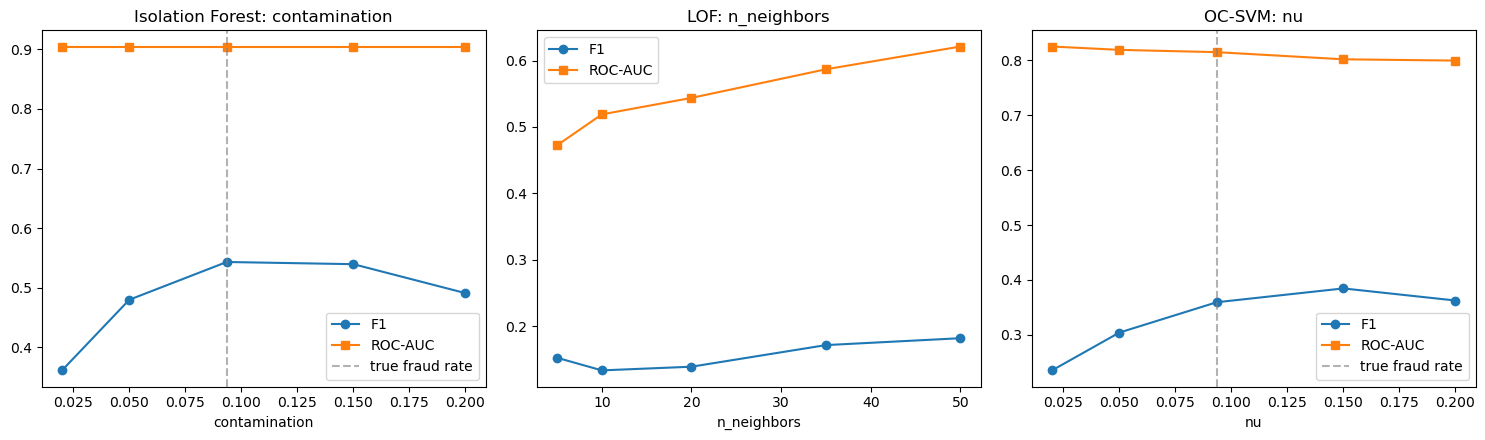

In [18]:
contam_values = [0.02, 0.05, 0.0935, 0.15, 0.20]
iso_f1, iso_roc = [], []
for c in contam_values:
    m = IsolationForest(contamination=c, random_state=42, n_estimators=200)
    m.fit(X_train_scaled)
    pred = (m.predict(X_test_scaled) == -1).astype(int)
    score = -m.score_samples(X_test_scaled)
    iso_f1.append(f1_score(y_test, pred, zero_division=0))
    iso_roc.append(roc_auc_score(y_test, score))
 
k_values = [5, 10, 20, 35, 50]
lof_f1, lof_roc = [], []
for k in k_values:
    m = LocalOutlierFactor(n_neighbors=k, contamination=fraud_rate_train, novelty=True)
    m.fit(X_train_scaled)
    pred = (m.predict(X_test_scaled) == -1).astype(int)
    score = -m.decision_function(X_test_scaled)
    lof_f1.append(f1_score(y_test, pred, zero_division=0))
    lof_roc.append(roc_auc_score(y_test, score))
 
nu_values = [0.02, 0.05, 0.0935, 0.15, 0.20]
ocsvm_f1, ocsvm_roc = [], []
for nu in nu_values:
    m = OneClassSVM(nu=nu, kernel="rbf", gamma="auto")
    m.fit(X_train_scaled)
    pred = (m.predict(X_test_scaled) == -1).astype(int)
    score = -m.decision_function(X_test_scaled)
    ocsvm_f1.append(f1_score(y_test, pred, zero_division=0))
    ocsvm_roc.append(roc_auc_score(y_test, score))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(contam_values, iso_f1, "o-", label="F1")
axes[0].plot(contam_values, iso_roc, "s-", label="ROC-AUC")
axes[0].axvline(0.0935, color="gray", linestyle="--", alpha=0.6, label="true fraud rate")
axes[0].set_title("Isolation Forest: contamination"); axes[0].set_xlabel("contamination"); axes[0].legend()
 
axes[1].plot(k_values, lof_f1, "o-", label="F1")
axes[1].plot(k_values, lof_roc, "s-", label="ROC-AUC")
axes[1].set_title("LOF: n_neighbors"); axes[1].set_xlabel("n_neighbors"); axes[1].legend()
 
axes[2].plot(nu_values, ocsvm_f1, "o-", label="F1")
axes[2].plot(nu_values, ocsvm_roc, "s-", label="ROC-AUC")
axes[2].axvline(0.0935, color="gray", linestyle="--", alpha=0.6, label="true fraud rate")
axes[2].set_title("OC-SVM: nu"); axes[2].set_xlabel("nu"); axes[2].legend()
 
plt.tight_layout()
plt.savefig(path + r"\fig_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

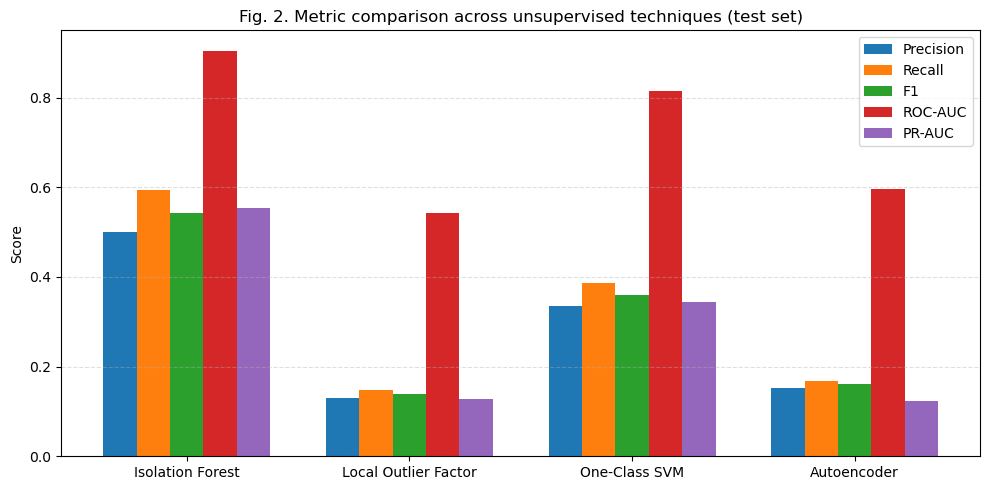

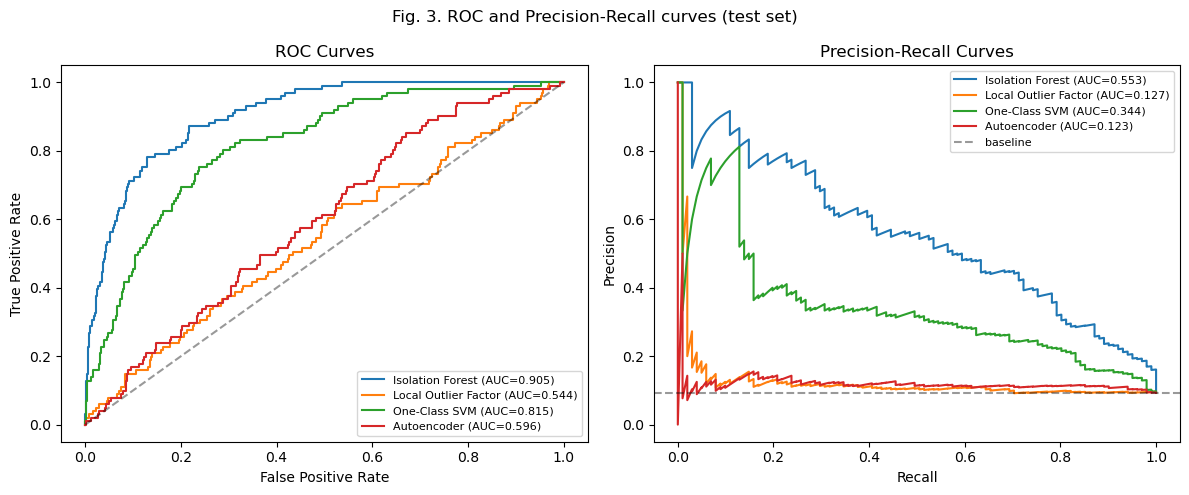

In [21]:
# ---- Fig. 2: Bar chart comparison across all metrics ----
methods = ["Isolation Forest", "Local Outlier Factor", "One-Class SVM", "Autoencoder"]
metrics_to_plot = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(methods))
width = 0.15
for i, metric in enumerate(metrics_to_plot):
    values = [results_test[m][metric] for m in methods]
    ax.bar(x + i * width, values, width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(methods)
ax.set_ylabel("Score")
ax.set_title("Fig. 2. Metric comparison across unsupervised techniques (test set)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(path + r"\fig2_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Fig. 3: ROC curves and PR curves, all four methods ----
from sklearn.metrics import roc_curve, precision_recall_curve

score_dict_test = {
    "Isolation Forest": iso_test_score,
    "Local Outlier Factor": lof_test_score,
    "One-Class SVM": ocsvm_test_score,
    "Autoencoder": ae_test_score,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, score in score_dict_test.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results_test[name]['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=8)

for name, score in score_dict_test.items():
    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec, prec, label=f"{name} (AUC={results_test[name]['PR-AUC']:.3f})")
axes[1].axhline(fraud_rate_train, color="k", linestyle="--", alpha=0.4, label="baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(fontsize=8)

plt.suptitle("Fig. 3. ROC and Precision-Recall curves (test set)")
plt.tight_layout()
plt.savefig(path + r"\fig3_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# ============================================================
# Case studies: Isolation Forest results on real providers
# (uses the test-set split already in memory — no file reload needed)
# ============================================================
merged = df.loc[idx_test].copy()
merged["IsoForest_Pred"] = iso_test_pred
merged["Isolation Forest"] = iso_test_score
merged["FraudLabel"] = y_test

avg = merged[["num_claims", "num_unique_patients", "total_reimbursed",
              "avg_reimbursed", "claims_per_patient", "reimbursed_per_patient",
              "num_unique_attending_phys"]].mean()

def describe_case(row, label):
    lines = [f"\n### {label}: Provider {row['Provider']}"]
    lines.append(f"- Total claims filed: {row['num_claims']:.0f} (dataset average: {avg['num_claims']:.0f})")
    lines.append(f"- Unique patients treated: {row['num_unique_patients']:.0f} (average: {avg['num_unique_patients']:.0f})")
    lines.append(f"- Total amount reimbursed: {row['total_reimbursed']:.0f} (average: {avg['total_reimbursed']:.0f})")
    lines.append(f"- Average reimbursement per claim: {row['avg_reimbursed']:.0f} (average: {avg['avg_reimbursed']:.0f})")
    lines.append(f"- Claims per patient: {row['claims_per_patient']:.2f} (average: {avg['claims_per_patient']:.2f})")
    lines.append(f"- Unique attending physicians: {row['num_unique_attending_phys']:.0f} (average: {avg['num_unique_attending_phys']:.0f})")
    lines.append(f"- Isolation Forest anomaly score: {row['Isolation Forest']:.3f}")
    return "\n".join(lines)

report = []
report.append("=" * 70)
report.append("CASE STUDIES: Isolation Forest Results on Held-Out Test Providers")
report.append("=" * 70)

report.append("\n\n## CATEGORY 1: Correctly Detected Fraud (True Positives)")
report.append("These are real fraudulent providers the model correctly flagged.")
tp = merged[(merged["IsoForest_Pred"] == 1) & (merged["FraudLabel"] == 1)] \
    .sort_values("Isolation Forest", ascending=False).head(4)
for _, row in tp.iterrows():
    report.append(describe_case(row, "TRUE POSITIVE (correctly caught)"))

report.append("\n\n## CATEGORY 2: Missed Fraud (False Negatives)")
report.append("These providers were genuinely fraudulent but the model did NOT flag them --")
report.append("useful for discussing the model's limitations.")
fn = merged[(merged["IsoForest_Pred"] == 0) & (merged["FraudLabel"] == 1)] \
    .sort_values("Isolation Forest", ascending=False).head(3)
for _, row in fn.iterrows():
    report.append(describe_case(row, "FALSE NEGATIVE (missed)"))

report.append("\n\n## CATEGORY 3: False Alarms (False Positives)")
report.append("These providers were flagged as suspicious but were NOT actually fraudulent --")
report.append("useful for discussing why large/complex providers can look anomalous even when legitimate.")
fp = merged[(merged["IsoForest_Pred"] == 1) & (merged["FraudLabel"] == 0)] \
    .sort_values("Isolation Forest", ascending=False).head(3)
for _, row in fp.iterrows():
    report.append(describe_case(row, "FALSE POSITIVE (false alarm)"))

report.append("\n\n## CATEGORY 4: Typical Normal Provider (for comparison)")
normal = merged[(merged["IsoForest_Pred"] == 0) & (merged["FraudLabel"] == 0)]
typical = normal.iloc[(normal["num_claims"] - avg["num_claims"]).abs().argsort()[:1]]
for _, row in typical.iterrows():
    report.append(describe_case(row, "TYPICAL NORMAL PROVIDER"))

output = "\n".join(report)
print(output)

with open(path + r"\case_studies.txt", "w") as f:
    f.write(output)
print("\n\nSaved to case_studies.txt")

CASE STUDIES: Isolation Forest Results on Held-Out Test Providers


## CATEGORY 1: Correctly Detected Fraud (True Positives)
These are real fraudulent providers the model correctly flagged.

### TRUE POSITIVE (correctly caught): Provider PRV55215
- Total claims filed: 3393 (dataset average: 124)
- Unique patients treated: 2638 (average: 78)
- Total amount reimbursed: 2284560 (average: 116143)
- Average reimbursement per claim: 673 (average: 1726)
- Claims per patient: 1.29 (average: 1.32)
- Unique attending physicians: 544 (average: 18)
- Isolation Forest anomaly score: 0.721

### TRUE POSITIVE (correctly caught): Provider PRV51578
- Total claims filed: 1500 (dataset average: 124)
- Unique patients treated: 1280 (average: 78)
- Total amount reimbursed: 1662920 (average: 116143)
- Average reimbursement per claim: 1109 (average: 1726)
- Claims per patient: 1.17 (average: 1.32)
- Unique attending physicians: 231 (average: 18)
- Isolation Forest anomaly score: 0.692

### TRUE POSITIVE (cor